In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
!pip install deepinv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 850.4/850.4 kB 6.9 MB/s eta 0:00:00a 0:00:01


In [5]:
import torch
import deepinv
from torchvision import datasets,transforms

In [6]:
device='cuda:0'
batch_size=32
image_size=32

In [7]:
transform=transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.0,),(1.0,)),
])

In [8]:
dataset=datasets.MNIST(root="./data",train=True,download=True,transform=transform)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.20MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 165kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.70MB/s]


In [9]:
trainloader=torch.utils.data.DataLoader(dataset=dataset,batch_size=batch_size,shuffle=True)

In [10]:
lr=1e-4
epochs=100

In [11]:
model=deepinv.models.DiffUNet(in_channels=1,out_channels=1,pretrained=None).to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=lr)
loss_function= deepinv.loss.MSE()

In [12]:
beta_start=1e-4
beta_end=0.02
timesteps=1000

In [13]:
betas=torch.linspace(beta_start,beta_end,timesteps,device=device)
alphas=1.0-betas
alphas_cumprod=torch.cumprod(alphas,dim=0)
sqrt_alphas_cumprod=torch.sqrt(alphas_cumprod)
sqrt_ones_minus_alphas_cumprod=torch.sqrt(1.0-alphas_cumprod)

In [14]:
running_loss=0.0
for epoch in range(epochs):
    epoch_loss, n_batches = 0.0, 0
    model.train()
    for data,_ in trainloader:
        imgs=data.to(device)
        noise=torch.randn_like(imgs)
        t=torch.randint(0,timesteps,(imgs.size(0),),device=device)
        noised_imgs=(sqrt_alphas_cumprod[t,None,None,None]*imgs
                     + sqrt_ones_minus_alphas_cumprod[t,None,None,None]*noise)
        optimizer.zero_grad()
        estimated_noise=model(noised_imgs,t,type_t="timestep")
        loss=loss_function(estimated_noise,noise).mean() 
        epoch_loss+=loss.item()
        loss.backward()
        optimizer.step()
        n_batches  += 1
        if n_batches % 100 == 0:
            print(f"  Epoch {epoch+1}/{epochs}  Batch {n_batches}  "
                      f"Loss {epoch_loss/n_batches:.5f}")
    running_loss=epoch_loss/max(n_batches, 1)
    print(f"  ── Epoch {epoch+1} done  avg_loss={loss:.5f}")
torch.save(model.state_dict(),"trained_diffusion_model.pth")
print("Model saved")

  Epoch 1/100  Batch 100  Loss 0.20610
  Epoch 1/100  Batch 200  Loss 0.11326
  Epoch 1/100  Batch 300  Loss 0.08155
  Epoch 1/100  Batch 400  Loss 0.06522
  Epoch 1/100  Batch 500  Loss 0.05552
  Epoch 1/100  Batch 600  Loss 0.04888
  Epoch 1/100  Batch 700  Loss 0.04397
  Epoch 1/100  Batch 800  Loss 0.04031
  Epoch 1/100  Batch 900  Loss 0.03739
  Epoch 1/100  Batch 1000  Loss 0.03494
  Epoch 1/100  Batch 1100  Loss 0.03303
  Epoch 1/100  Batch 1200  Loss 0.03137
  Epoch 1/100  Batch 1300  Loss 0.02995
  Epoch 1/100  Batch 1400  Loss 0.02880
  Epoch 1/100  Batch 1500  Loss 0.02777
  Epoch 1/100  Batch 1600  Loss 0.02681
  Epoch 1/100  Batch 1700  Loss 0.02598
  Epoch 1/100  Batch 1800  Loss 0.02520
  ── Epoch 1 done  avg_loss=0.00980
  Epoch 2/100  Batch 100  Loss 0.01214
  Epoch 2/100  Batch 200  Loss 0.01251
  Epoch 2/100  Batch 300  Loss 0.01244
  Epoch 2/100  Batch 400  Loss 0.01240
  Epoch 2/100  Batch 500  Loss 0.01234
  Epoch 2/100  Batch 600  Loss 0.01230
  Epoch 2/100  Batc

In [19]:
torch.save(model.state_dict(), "trained_diffusion_model.pth")

In [20]:
from pathlib import Path

checkpoint_path = "./trained_diffusion_model.pth"

# load model without pretrained first
model = deepinv.models.DiffUNet(in_channels=1, out_channels=1, pretrained=None).to(device)

# load checkpoint manually, filtering out extra keys
ckpt = torch.load(checkpoint_path, map_location=device)

# filter only keys that belong to the model
model_keys = set(model.state_dict().keys())
filtered_ckpt = {k: v for k, v in ckpt.items() if k in model_keys}

model.load_state_dict(filtered_ckpt, strict=True)
model.eval()
print(f"✅ Loaded {len(filtered_ckpt)}/{len(ckpt)} keys")
print(f"⚠️  Skipped keys: {set(ckpt.keys()) - model_keys}")



✅ Loaded 364/364 keys
⚠️  Skipped keys: set()


In [25]:
import matplotlib.pyplot as plt

n_samples = 8
beta_start = 1e-4
beta_end = 0.02
timesteps = 1000
betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

with torch.no_grad():
    x = torch.randn(n_samples, 1, image_size, image_size).to(device)
    for t in reversed(range(timesteps)):
        t_tensor = torch.ones(n_samples, device=device).long() * t
        predicted_noise = model(x, t_tensor, type_t="timestep")
        alpha = alphas[t]
        alpha_cumprod = alphas_cumprod[t]
        beta = betas[t]
        noise = torch.randn_like(x) if t > 0 else 0
        x = (1 / torch.sqrt(alpha)) * (
            x - (beta / torch.sqrt(1 - alpha_cumprod)) * predicted_noise
        ) + torch.sqrt(beta) * noise



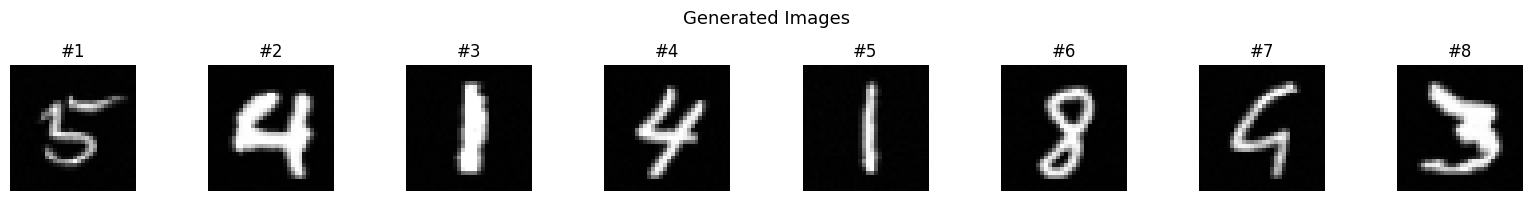

In [26]:

x = x.clamp(-1, 1)                          
x = (x + 1) / 2                            
x = x.cpu()

fig, axes = plt.subplots(1, n_samples, figsize=(2 * n_samples, 2))
for i, ax in enumerate(axes):
    ax.imshow(x[i, 0], cmap="gray")
    ax.axis("off")
    ax.set_title(f"#{i+1}")

plt.suptitle("Generated Images", fontsize=13)
plt.tight_layout()
plt.show()